
В данном разделе проводится разведочный анализ данных (EDA), предоставленных химиками.

Цель анализа:
- изучить структуру данных
- выявить особенности распределения признаков
- определить наличие выбросов и пропусков
- понять взаимосвязи между параметрами

Результаты анализа будут использованы для подготовки данных и выбора подходящих моделей машинного обучения.

# Загрузка данных

На данном этапе выполняется загрузка данных и их первичный осмотр.

Необходимо:
- определить размер датасета
- проверить типы данных
- выявить возможные технические или служебные признаки

In [135]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np

df = pd.read_excel("../data/compounds.xlsx")

print(df.shape)

(1001, 214)


In [136]:
df = df.drop(columns=["Unnamed: 0"])

In [137]:
df.head()

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,...,0,0,0,0,0,0,0,0,3,0
1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,...,0,0,0,0,0,0,0,0,3,0
2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,...,0,0,0,0,0,0,0,0,3,0
3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,...,0,0,0,0,0,0,0,0,4,0
4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,...,0,0,0,0,0,0,0,0,0,0


In [138]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Columns: 213 entries, IC50, mM to fr_urea
dtypes: float64(107), int64(106)
memory usage: 1.6 MB


# Анализ целевых переменных

Целевые переменные (IC50, CC50, SI) являются ключевыми для задачи, поэтому необходимо изучить их распределение.

Это позволит:
- выявить асимметрию
- обнаружить выбросы
- определить необходимость преобразований

In [139]:
targets = ["IC50, mM", "CC50, mM", "SI"]

df[targets].describe().T

,count,mean,std,min,25%,50%,75%,max
"IC50, mM",1001.0,222.805156,402.169734,0.003517,12.515396,46.585183,224.975928,4128.529377
"CC50, mM",1001.0,589.110728,642.867508,0.700808,99.999036,411.039342,894.089176,4538.976189
SI,1001.0,72.508823,684.482739,0.011489,1.433333,3.846154,16.566667,15620.600000


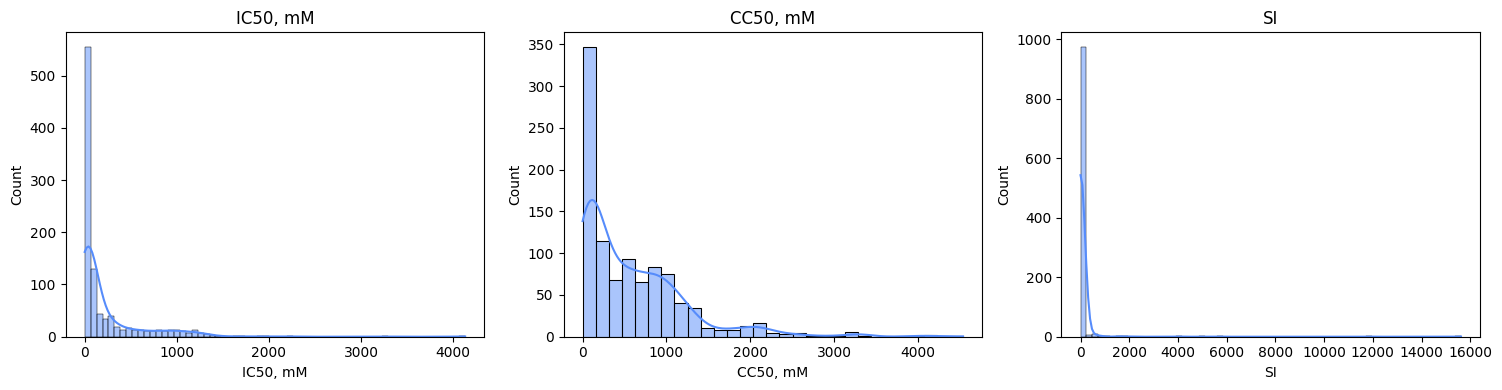

In [140]:
fig, axes = plt.subplots(1, len(targets), figsize=(15, 4))

if len(targets) == 1:
    axes = [axes]

for i, col in enumerate(targets):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

Распределения всех целевых переменных имеют выраженную правостороннюю асимметрию:
- большинство значений сосредоточено в области малых значений
- присутствует длинный хвост и выбросы

Особенно это заметно для SI, где наблюдаются экстремально большие значения.

Такая структура данных может негативно влиять на качество моделей, особенно линейных, поэтому требуется преобразование.

# Логарифмическое преобразование

Для корректной работы моделей важно, чтобы распределения целевых переменных были близки к симметричным.

В случае сильной асимметрии применяется логарифмическое преобразование, позволяющее:
- уменьшить влияние выбросов
- стабилизировать разброс значений
- улучшить качество моделей

In [141]:
for col in targets:
    df[f"log_{col}"] = np.log1p(df[col])

target_cols = ["IC50, mM", "CC50, mM", "SI"]
log_target_cols = [f"log_{col}" for col in target_cols]

feature_cols = [
    col for col in df.columns
    if col not in target_cols + log_target_cols
]

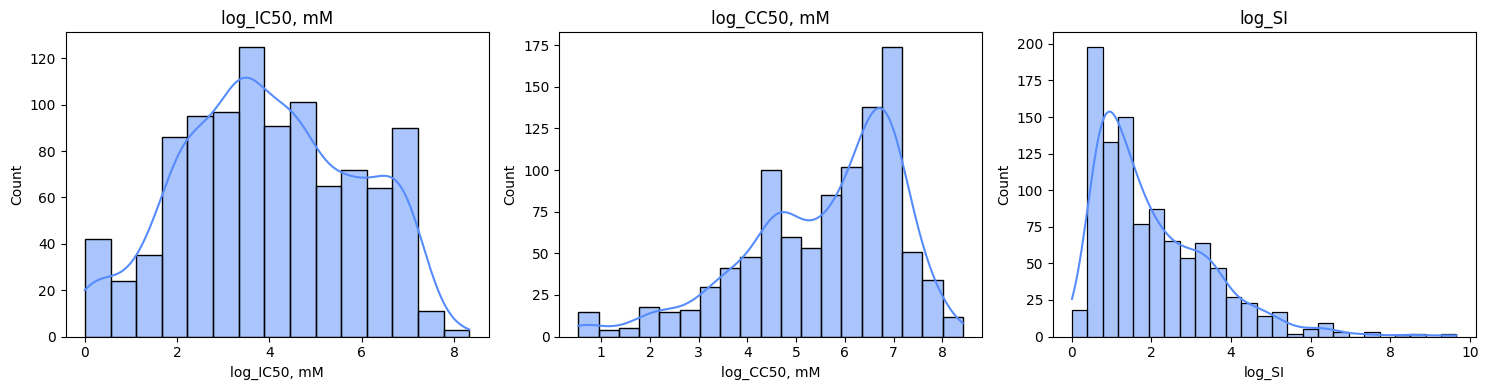

In [142]:
fig, axes = plt.subplots(1, len(targets), figsize=(15, 4))

if len(targets) == 1:
    axes = [axes]

for i, col in enumerate(targets):
    sns.histplot(df[f"log_{col}"], kde=True, ax=axes[i])
    axes[i].set_title(f"log_{col}")

plt.tight_layout()
plt.show()

После логарифмического преобразования распределения становятся более симметричными и приближаются к нормальным.

Это позволяет:
- уменьшить влияние выбросов
- стабилизировать разброс значений
- улучшить качество моделей, особенно чувствительных к масштабу данных

В дальнейшем модели будут обучаться на логарифмированных значениях целевых переменных.

# Анализ зависимостей

Для понимания структуры данных проводится анализ зависимостей между переменными.

Особое внимание уделяется связи SI с IC50 и CC50, так как SI рассчитывается на их основе.

Это важно для:
- выявления структуры зависимостей
- предотвращения утечки данных при моделировании

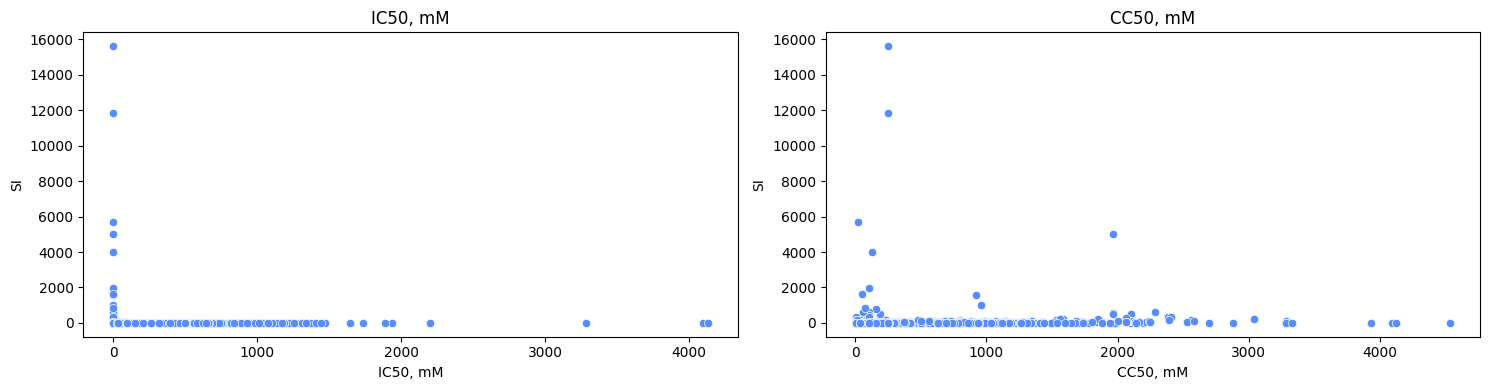

In [143]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

sns.scatterplot(x=df["IC50, mM"], y=df["SI"], ax=axes[0])
axes[0].set_title("IC50, mM")
sns.scatterplot(x=df["CC50, mM"], y=df["SI"], ax=axes[1])
axes[1].set_title("CC50, mM")

plt.tight_layout()
plt.show()

Анализ зависимостей показывает, что:
- явной линейной зависимости между переменными не наблюдается
- данные имеют сложную нелинейную структуру
- присутствует сильное влияние выбросов

При этом видно, что SI функционально связан с IC50 и CC50, что соответствует теоретической формуле.

Это означает, что при моделировании SI необходимо исключить IC50 и CC50 из признаков, чтобы избежать утечки данных.

# Анализ распределения признаков

## Асиметрия признаков

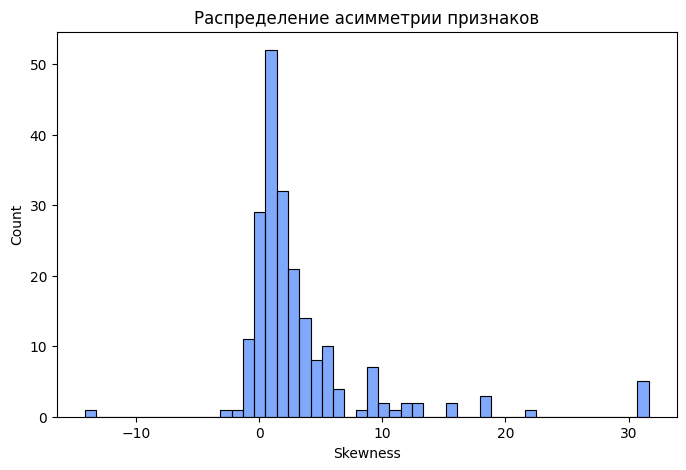

In [144]:
skewness = df[feature_cols].skew().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.histplot(skewness, bins=50)
plt.title("Распределение асимметрии признаков")
plt.xlabel("Skewness")
plt.show()

## Дисперсия признаков

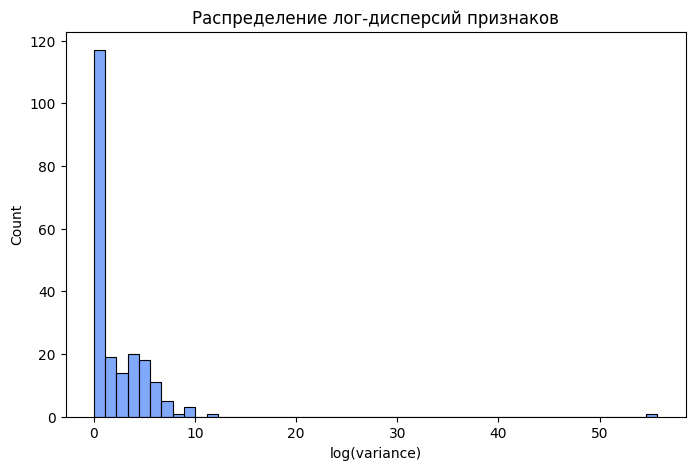

In [145]:
import numpy as np

variances = df[feature_cols].var().sort_values()

plt.figure(figsize=(8, 5))
sns.histplot(np.log1p(variances), bins=50)
plt.title("Распределение лог-дисперсий признаков")
plt.xlabel("log(variance)")
plt.show()

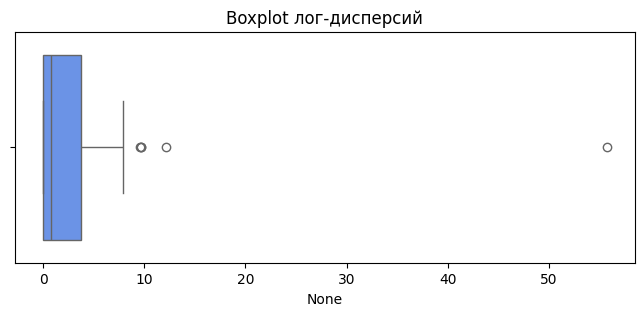

In [146]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=np.log1p(variances))
plt.title("Boxplot лог-дисперсий")
plt.show()

Анализ распределения признаков показывает, что признаки имеют разный масштаб и различную степень асимметрии.

Часть признаков имеет выраженную асимметрию, а разброс дисперсий отличается на несколько порядков. Это означает, что перед применением моделей, чувствительных к масштабу признаков, необходимо использовать масштабирование.

Для моделей на основе деревьев масштабирование менее критично, но для линейных моделей, KNN и PCA оно важно.

## Распределение корреляций признаков с целевыми переменными

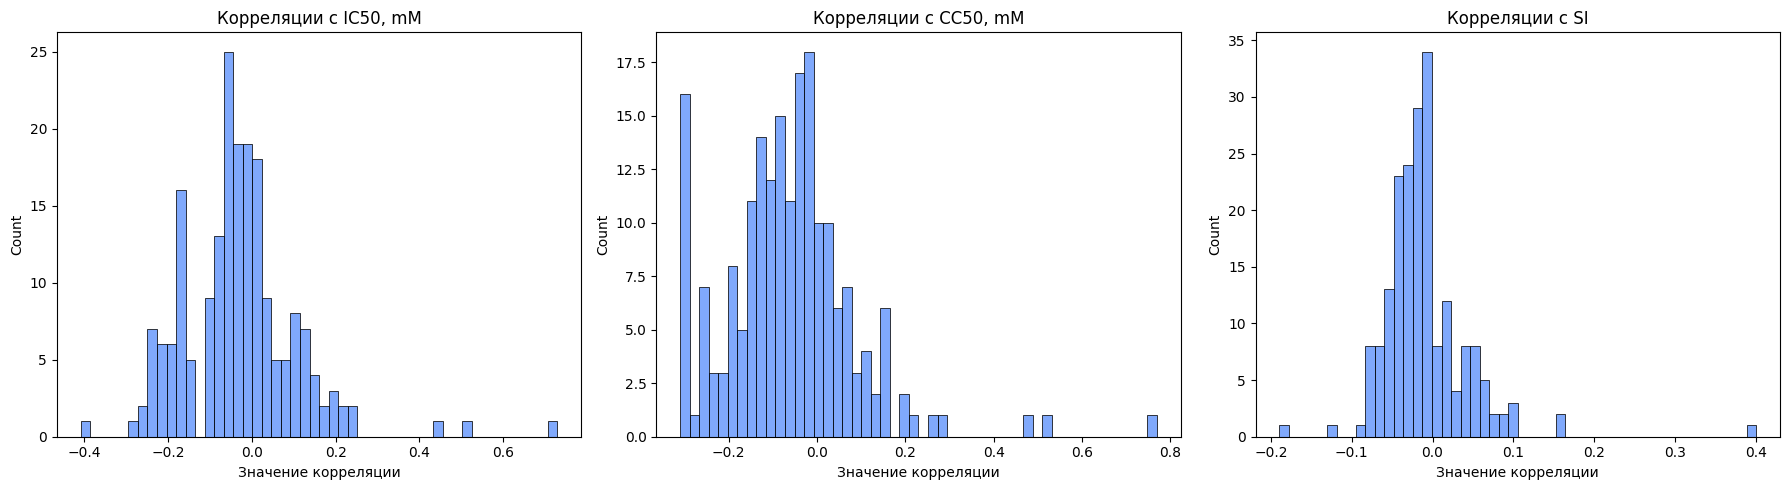

In [147]:
import seaborn as sns
import matplotlib.pyplot as plt

targets = ["IC50, mM", "CC50, mM", "SI"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, target in enumerate(targets):
    corr = df.corr(numeric_only=True)[target].drop(target)

    sns.histplot(corr, bins=50, ax=axes[i])
    axes[i].set_title(f"Корреляции с {target}")
    axes[i].set_xlabel("Значение корреляции")

plt.tight_layout()
plt.show()

Большинство признаков имеют слабую линейную корреляцию с целевыми переменными.

Это говорит о том, что задача не сводится к простой линейной зависимости. Поэтому в дальнейшем важно сравнить линейные модели с более гибкими алгоритмами, например ансамблями деревьев.

# Пропуски
Наличие пропущенных значений может негативно влиять на качество моделей.

На данном этапе:
- оценивается количество пропусков
- выбирается стратегия их обработки

In [148]:
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]

BCUT2D_CHGHI           3
MaxAbsPartialCharge    3
BCUT2D_MWLOW           3
BCUT2D_MWHI            3
MinPartialCharge       3
MinAbsPartialCharge    3
MaxPartialCharge       3
BCUT2D_CHGLO           3
BCUT2D_MRHI            3
BCUT2D_LOGPLOW         3
BCUT2D_LOGPHI          3
BCUT2D_MRLOW           3
dtype: int64

Количество пропусков в данных незначительное, поэтому их можно заменить медианными значениями.

Использование медианы предпочтительно, так как данные содержат выбросы и имеют асимметричное распределение.

# Удаление константных признаков

Признаки с нулевой или очень малой дисперсией не несут полезной информации для моделей.

Удаление таких признаков позволяет:
- уменьшить размерность данных
- ускорить обучение моделей

In [149]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.0)
selector.fit(df)

low_var_cols = df.columns[~selector.get_support()]
print(low_var_cols)
df = df.drop(columns=low_var_cols)

Index(['NumRadicalElectrons', 'SMR_VSA8', 'SlogP_VSA9', 'fr_N_O', 'fr_SH',
       'fr_azide', 'fr_barbitur', 'fr_benzodiazepine', 'fr_diazo',
       'fr_dihydropyridine', 'fr_isocyan', 'fr_isothiocyan', 'fr_lactam',
       'fr_nitroso', 'fr_phos_acid', 'fr_phos_ester', 'fr_prisulfonamd',
       'fr_thiocyan'],
      dtype='object')


# PCA анализ

PCA используется для оценки общей структуры признакового пространства и понимания того, можно ли описать данные меньшим числом компонент.

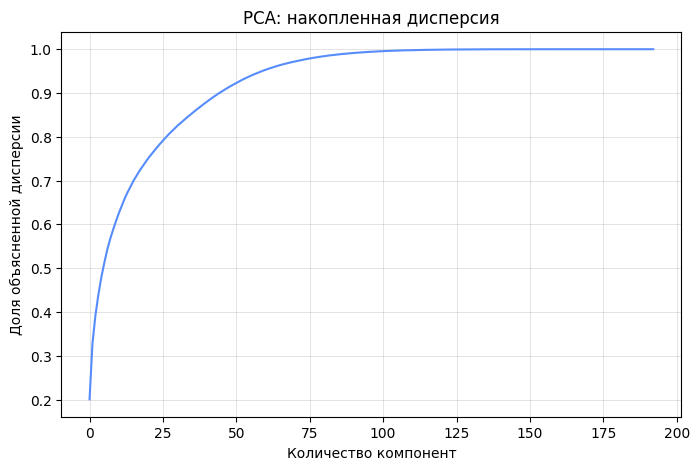

In [157]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

target_cols = ["IC50, mM", "CC50, mM", "SI"]
log_target_cols = [f"log_{col}" for col in target_cols]

feature_cols = [
    col for col in df.columns
    if col not in target_cols + log_target_cols
]

X = df[feature_cols]

imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)
X_scaled = StandardScaler().fit_transform(X_imputed)

pca = PCA()
pca.fit(X_scaled)

explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(8, 5))
plt.plot(explained_variance.cumsum())
plt.xlabel("Количество компонент")
plt.ylabel("Доля объясненной дисперсии")
plt.title("PCA: накопленная дисперсия")
plt.grid()
plt.show()

Анализ PCA показывает, что значительная часть дисперсии объясняется первыми компонентами, однако для достижения уровня 95–99% требуется достаточно большое количество компонент.

Это говорит о том, что данные имеют высокую размерность, и информация распределена между большим числом признаков.

Таким образом, сильное сокращение размерности с помощью PCA может привести к потере информации, поэтому данный метод не будет использоваться как основной инструмент снижения размерности.

# Корреляционный анализ

Корреляционный анализ позволяет выявить линейные зависимости между признаками и целевыми переменными.

Это помогает:
- понять структуру данных
- выделить потенциально важные признаки
- оценить сложность задачи

In [151]:
corr = df.corr()

for target in targets:
    print(f"\nTop correlations with {target}")
    print(corr[target].abs().sort_values(ascending=False).head(10))


Top correlations with IC50, mM
IC50, mM        1.000000
log_IC50, mM    0.729335
CC50, mM        0.521346
log_CC50, mM    0.438169
log_SI          0.408830
VSA_EState4     0.274203
Chi2n           0.257058
PEOE_VSA7       0.255988
Chi2v           0.249164
fr_Nhpyrrole    0.245511
Name: IC50, mM, dtype: float64

Top correlations with CC50, mM
CC50, mM          1.000000
log_CC50, mM      0.769153
IC50, mM          0.521346
log_IC50, mM      0.475748
MolMR             0.310111
LabuteASA         0.309191
MolWt             0.306439
ExactMolWt        0.306382
HeavyAtomCount    0.305169
Chi0              0.304792
Name: CC50, mM, dtype: float64

Top correlations with SI
SI                  1.000000
log_SI              0.400597
log_IC50, mM        0.189414
BalabanJ            0.162955
fr_NH2              0.160470
RingCount           0.124444
fr_Al_COO           0.102414
fr_COO2             0.101115
fr_COO              0.101115
NumAromaticRings    0.088064
Name: SI, dtype: float64


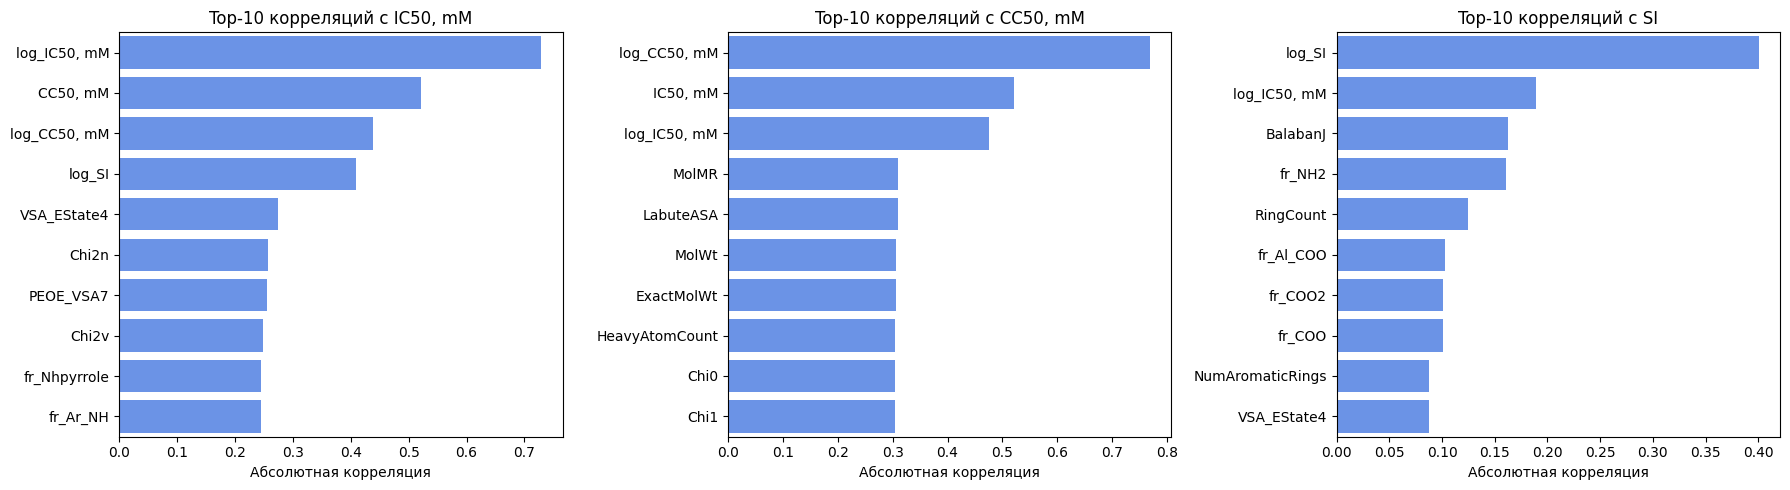

In [152]:
import seaborn as sns
import matplotlib.pyplot as plt

targets = ["IC50, mM", "CC50, mM", "SI"]

corr = df.corr(numeric_only=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, target in enumerate(targets):
    top_corr = (
        corr[target]
        .drop(target)
        .abs()
        .sort_values(ascending=False)
        .head(10)
    )

    sns.barplot(
        x=top_corr.values,
        y=top_corr.index,
        ax=axes[i]
    )

    axes[i].set_title(f"Top-10 корреляций с {target}")
    axes[i].set_xlabel("Абсолютная корреляция")
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

Анализ корреляции показывает, что:
- некоторые признаки имеют заметную связь с целевыми переменными
- при этом большинство признаков имеют слабую линейную зависимость

Это указывает на то, что задача имеет сложный характер и требует использования моделей, способных учитывать нелинейные зависимости (например, ансамбли деревьев).

# Анализ мультиколлинеарности

In [153]:
# топ корреляций между признаками
corr_matrix = df.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = [col for col in upper.columns if any(upper[col] > 0.9)]

print("Признаки с высокой корреляцией:", len(high_corr))
print(high_corr)

Признаки с высокой корреляцией: 47
['MaxEStateIndex', 'HeavyAtomMolWt', 'ExactMolWt', 'NumValenceElectrons', 'MaxAbsPartialCharge', 'MinAbsPartialCharge', 'FpDensityMorgan2', 'FpDensityMorgan3', 'BertzCT', 'Chi0', 'Chi0n', 'Chi0v', 'Chi1', 'Chi1n', 'Chi1v', 'Chi2n', 'Chi2v', 'Chi3n', 'Chi3v', 'Chi4n', 'Chi4v', 'HallKierAlpha', 'Kappa1', 'Kappa2', 'Kappa3', 'LabuteASA', 'SlogP_VSA11', 'SlogP_VSA6', 'VSA_EState6', 'HeavyAtomCount', 'NOCount', 'NumAromaticCarbocycles', 'NumHAcceptors', 'NumHDonors', 'NumHeteroatoms', 'NumSaturatedCarbocycles', 'MolMR', 'fr_Al_OH_noTert', 'fr_COO', 'fr_COO2', 'fr_C_O', 'fr_C_O_noCOO', 'fr_Nhpyrrole', 'fr_benzene', 'fr_nitro_arom_nonortho', 'fr_phenol', 'fr_phenol_noOrthoHbond']


# Анализ выбросов

Выбросы могут существенно влиять на модели и искажать результаты анализа.

На данном этапе оценивается:
- наличие выбросов
- их влияние на распределение данных
- необходимость их обработки


In [154]:
for col in targets:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    outliers = df[(df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)]
    print(col, len(outliers))

IC50, mM 147
CC50, mM 39
SI 125


В данных присутствует значительное количество выбросов, особенно в целевых переменных.

Удаление выбросов может привести к потере важной информации, поэтому было принято решение не удалять их, а учитывать при помощи логарифмического преобразования.

# Подтверждение расчетного характера SI

Согласно предметной области, показатель SI рассчитывается на основе IC50 и CC50.

На данном этапе проводится проверка этого утверждения на данных, чтобы:
- подтвердить корректность формулы
- учесть это при построении моделей

In [155]:
df["SI_calc"] = df["CC50, mM"] / df["IC50, mM"]

# корреляция
corr = df[["SI", "SI_calc"]].corr()
print(corr)

          SI  SI_calc
SI       1.0      1.0
SI_calc  1.0      1.0


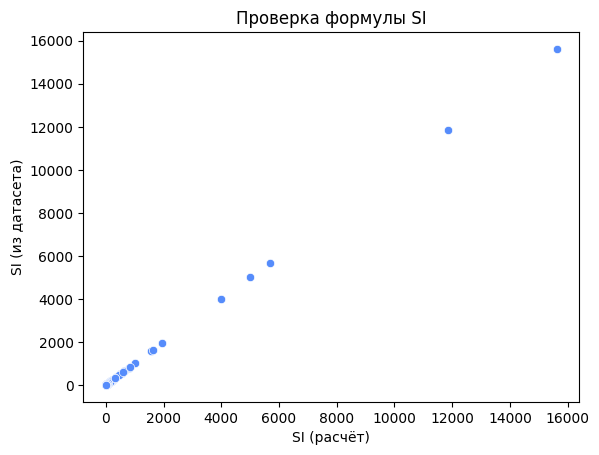

In [156]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x=df["SI_calc"], y=df["SI"])
plt.xlabel("SI (расчёт)")
plt.ylabel("SI (из датасета)")
plt.title("Проверка формулы SI")
plt.show()

Расчётное значение SI практически полностью совпадает с исходным значением из датасета, что подтверждает формулу:

SI = CC50 / IC50

Таким образом, SI является производной величиной и не может рассматриваться как независимая переменная.

Это критически важно для моделирования:
использование IC50 и CC50 в качестве признаков при предсказании SI приведёт к утечке данных и некорректным результатам.

Обнаружены сильно коррелирующие признаки, что может приводить к избыточности данных.

Для линейных моделей это может ухудшать устойчивость, однако ансамблевые методы менее чувствительны к данной проблеме.

# Выводы

В ходе разведочного анализа данных были выявлены следующие особенности.

Целевые переменные IC50, CC50 и SI имеют выраженную правостороннюю асимметрию и содержат значительное количество выбросов. Для стабилизации распределений и уменьшения влияния экстремальных значений было применено логарифмическое преобразование.

Анализ зависимостей показал отсутствие выраженных линейных связей между признаками и целевыми переменными. Это указывает на сложный нелинейный характер задачи.

Показатель SI является производной величиной, рассчитываемой на основе IC50 и CC50, что было подтверждено на данных. В связи с этим при построении моделей для SI признаки IC50 и CC50 будут исключены, чтобы избежать утечки данных.

Распределение дисперсий и анализ признаков показали, что признаки имеют различный масштаб и уровень вариативности. Это подтверждает необходимость масштабирования данных для ряда моделей.

Анализ мультиколлинеарности выявил наличие сильно коррелирующих признаков, что может приводить к избыточности информации. Однако для моделей на основе деревьев это не является критичной проблемой.

PCA-анализ показал, что информация распределена между большим числом признаков, и для объяснения значительной доли дисперсии требуется большое количество компонент. Это означает, что сильное сокращение размерности может привести к потере информации.

Таким образом, для решения задачи целесообразно использовать модели, способные учитывать нелинейные зависимости и устойчивые к выбросам, такие как ансамбли деревьев и бустинговые методы.
